# Deeltjes model

<!-- jupyter nbconvert --to notebook --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags="['solution']" \
  --output zonder_antwoorden.ipynb jouw_notebook.ipynb-->

```{exercise}
Bekijk onderstaande video.
```

```{iframe} https://www.youtube.com/embed/HEfHFsfGXjs?si=g37KWYOi0LqmuAkD
```

Je raadt het misschien al... deze simulatie gaan we na bouwen! Daarbij maken we gebruik van Python classes uit het vorige hoofdstuk en de basics van simulaties uit het hoofdstuk daarvoor. Zorg er dus voor dat je weet hoe dit werkt! We maken ook gebruik van plotten, en daarboven op een animatie. Hoe de animatie precies werkt en hoe je die zelf maakt hoef je niet te weten. Je zou wel in staat moeten zijn de code te lezen.

In onderstaande cell maken we de ParticleClass aan, en geven we enkele parameters van onze simulatie op.

In [2]:
# Importeren van libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Maken van de class
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  

    def update_position(self, dt):
        self.r += self.v * dt

# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particle = ParticleClass(m=1.0, v=[5.0, 0], r=[0.0, 0.0], R=1.0)  


We hebben nu een deeltje met massa, een snelheid, een begin positie en een straal. We hebben ook al de stapgrootte bepaald!

We willen de beweging van dat deeltje straks bestuderen en moeten dus een plot maken:

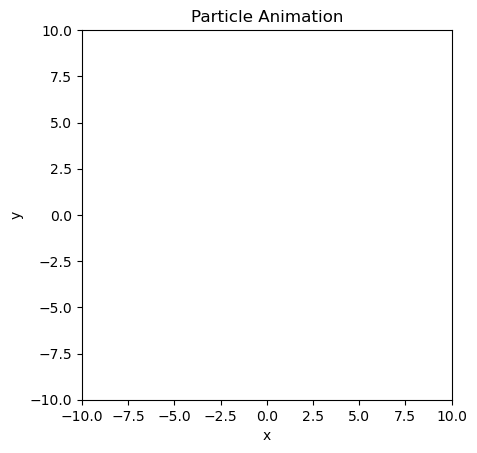

In [3]:
# Creeer een figuur en de assen
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Animatie")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Toon het deeltje als een rode stip
dot, = ax.plot([], [], 'ro', markersize=10); # semicolon to suppress output

In [4]:
# Initialisieren van de functie voor de animatie
def init():
    dot.set_data([], [])
    return dot,

# Updaten van de functie voor elk frame
def update(frame):
    particle.update_position(dt)
    dot.set_data([particle.r[0]], [particle.r[1]])
    return dot,

# Creeer de animatie
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# Omdat we werken met Jup. Notebooks (en niet een .py file)
from IPython.display import HTML
HTML(ani.to_jshtml())


Frames verwijst in FuncAnimation naar het totaal aantal frames dat gebruikt wordt. Interval naar de snelheid van de animatie, nl 50 milliseconden ofwel 20 frames per seconde.

Merk op dat als we de laatste cel opnieuw uitvoeren, het deeltje zich niet in de oorsprong bevindt. Dat is een 'eigenaardigheid' van Jupyter Notebooks. Het is nu beter om alle code in één cel te plaatsen (hieronder gedaan voor je), zodat we ervoor zorgen dat het deeltje altijd in de oorsprong begint.

Een van de dingen die je kunt opmerken, is dat het deeltje niet in zijn doos blijft.

```{exercise}
Verander de code zodat de doos een aaneengesloten doos is; als hij links eruit vliegt, komt hij er rechts in (en vice versa).
```

```{exercise}
Verbeter de code zodat het deeltje in zijn doos blijft.
```

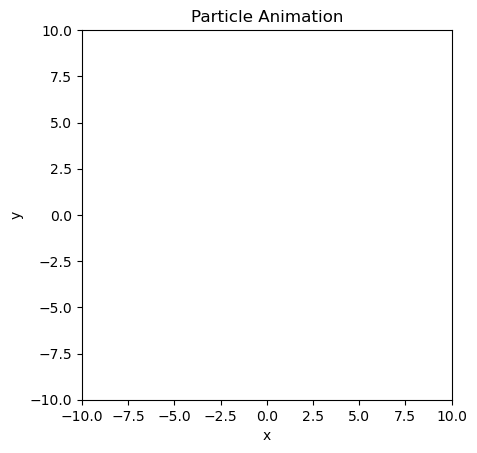

In [5]:
# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particle = ParticleClass(m=1.0, v=[5.0, 0], r=[0.0, 0.0],R=1.0)  

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Create the particle as a red dot
dot, = ax.plot([], [], 'ro', markersize=10)

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particle.update_position(dt)
    dot.set_data([particle.r[0]], [particle.r[1]])
    return dot,

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())


In [ ]:
### Jouw code

In [ ]:
### BEGIN_SOLUTION
# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particle = ParticleClass(m=1.0, v=[5.0, 0], r=[0.0, 0.0],R=1.0)  

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Create the particle as a red dot
dot, = ax.plot([], [], 'ro', markersize=10);

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particle.update_position(dt)
    dot.set_data([particle.r[0]], [particle.r[1]])
    if particle.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[0] = -particle.v[0]
        # particle.r[0] = -particle.r[0]
    return dot,


        # aanpassen want later wordt het dit:
        # if abs(self.r[0]) + self.R > Box_length: 
        #     self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
        #     self.r[0] = np.sign(self.r[0]) * (box_length - self.R)  # Zet terug net binnen box                 
        # if abs(self.r[1]) + self.R > Box_length: 
        #     self.v[1] = -self.v[1]     
        #     self.r[1] =  = np.sign(self.r[1]) * (box_length - self.R) 



# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

```{exercise}
Verander nu de code zodanig dat de snelheid gegeven wordt door $\vec{v}=5\hat{x} + 3\hat{y}$ en het deeltje botst tegen alle muren.
```

In [ ]:
### Jouw code

In [ ]:
### BEGIN_SOLUTION
# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particle = ParticleClass(m=1.0, v=[5.0, 3.0], r=[0.0, 0.0],R=1.0)  

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Create the particle as a red dot
dot, = ax.plot([], [], 'ro', markersize=10);

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particle.update_position(dt)
    dot.set_data([particle.r[0]], [particle.r[1]])
    if particle.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[0] = -particle.v[0]
    if particle.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[1] = -particle.v[1]
    return dot,

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

Laten we teruggaan naar ons deeltje. Er is een functie om de positie bij te werken, hoewel de snelheid hetzelfde lijkt te blijven... kunnen we de snelheid veranderen door (bijvoorbeeld) de versnelling door de zwaartekracht?

```{exercise}
Hieronder is de ParticleClass aangepast zodat er gebruik gemaakt kan worden van een versnelling. Maak de simulatie van het deeltje zodat het zich beweegt in een zwaartekrachtsveld met $a = -9.81\hat{y}$. 

In [ ]:
# Maken van de class met versnelling
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  # mass of the particle
        self.v = np.array(v, dtype=float)  # velocity vector
        self.r = np.array(r, dtype=float)  # position vector
        self.R = np.array(R, dtype=float)  # radius of the particle

    def update_position(self, dt):
        self.r += self.v * dt
    
    def update_velocity(self, a, dt):
        self.v += a*dt
    
    ### Jouw code

In [ ]:
### BEGIN_SOLUTION
# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particle = ParticleClass(m=1.0, v=[5.0, 0], r=[0.0, 0.0],R=1.0)  
a = np.array([0.0, -5.0])  

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Create the particle as a red dot
dot, = ax.plot([], [], 'ro', markersize=10);

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particle.update_velocity(a, dt)
    particle.update_position(dt)
    
    dot.set_data([particle.r[0]], [particle.r[1]])
    if particle.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[0] = -particle.v[0]
    if particle.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[1] = -particle.v[1]
    return dot,

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

Wat valt je op aan het behoud van energie?! Herinner wat we in basics hebben gedaan. 

Een optie om de simulatie te verbeteren is de tijdstap $\Delta t$ kleiner te maken, maar dan hebben we ook meer geduld meer nodig - het aantal berekeningen schaalt met $\frac{1}{\Delta t}$. Een tweede optie is een meer directe oplossing: We weten dat $a = const.$ en daarom weten we ook de bewegingsvergelijking van het deeltje!

Daarnaast willen we graag weten waar het deeltje is geweest, dat is in onderstaande code toegevoegd.

In [ ]:
# Maken van de class met versnelling
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  

    def update_position(self, dt):
        self.r += self.v * dt + 1/2 * a * dt**2  
    
    def update_velocity(self, a, dt):
        """Update the particle's velocity."""
        self.v += a*dt

# Simulation parameters
dt = 0.1         
num_steps = 500  
particle = ParticleClass(m=1.0, v=[0, 0], r=[0.0, 0.0],R=1.0)  
a = np.array([0.0, -5.0])  

track_x = []
track_y = []

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
track_line, = ax.plot([], [], 'r--', linewidth=1)  

# Create the particle as a red dot
dot, = ax.plot([], [], 'ro', markersize=10);

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particle.update_position(dt)
    particle.update_velocity(a, dt)

    track_x.append(particle.r[0])
    track_y.append(particle.r[1])
    track_line.set_data(track_x, track_y)
    
    dot.set_data([particle.r[0]], [particle.r[1]])
    if particle.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[0] = -particle.v[0]
    if particle.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particle.v[1] = -particle.v[1]
    return dot, track_line

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

We hebben steeds slechts gewerkt met een enkel deeltje. Maar om de simulatie uit het filmpje te maken, hebben we twee deeltjes nodig. 

```{exercise}
Maak de code hieronder voor twee deeltjes die bewegen in een afgesloten doos. Beide deeltjes ondervinden een zwaartekracht. Beide deeltjes starten op hetzelfde punt, zonder beginsnelheid in de verticale richting. Echter, een van de twee deeltjes heeft een initiële horizontale snelheid.
```


In [ ]:
### Jouw code


In [ ]:
### BEGIN_SOLUTION
# Simulation parameters
dt = 0.1         # time step
num_steps = 500  # number of time steps
particleA = ParticleClass(m=1.0, v=[0, 0], r=[0.0, 0.0],R=1.0)  
particleB = ParticleClass(m=1.0, v=[5.0, 0], r=[0.0, 0.0],R=1.0)

a = np.array([0.0, -5.0])  

track_x = []
track_y = []

# Create the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
track_line, = ax.plot([], [], 'r--', linewidth=1)  

# Create the particle as a red dot
dotA, = ax.plot([], [], 'ro', markersize=10)
dotB, = ax.plot([], [], 'bo', markersize=10)

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particleA.update_position(dt)
    particleA.update_velocity(a, dt)

    particleB.update_position(dt)
    particleB.update_velocity(a, dt)

    track_x.append(particleA.r[0])
    track_y.append(particleA.r[1])
    track_line.set_data(track_x, track_y)
    
    dotA.set_data([particleA.r[0]], [particleA.r[1]])
    dotB.set_data([particleB.r[0]], [particleB.r[1]])

    if particleA.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[0] = -particleA.v[0]
    if particleA.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[1] = -particleA.v[1]

    if particleB.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[0] = -particleB.v[0]
    if particleB.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[1] = -particleB.v[1]

    return dot, track_line

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

```{exercise}
Laat je werk controleren en aftekenen door de TA, dan gaan we daarna aan de slag met de echte botsingsmodel.
```